# Caregiver Survey Response Review

Two studies fed this review.

- **Study 1, the verified caregiver sample.** 177 people we know are real caregivers. This is the control group.
- **Study 2, the online recruitment sample.** 1,779 sign-ups that we have to decide whether to pay.

Every response answered the same four sections: **Family Information**, **Values**, **Thoughts, Feelings, and Attitudes**, and **Demographics**. That is 1,956 responses in total.

This notebook answers eight questions in order.

1. What is the rule, and where did every number in it come from?
2. What did a flagged response actually answer, next to what a real caregiver actually answered?
3. Do those patterns hold across all 1,956 responses?
4. What does the rule produce, and what does it miss?
5. What happens when the checks are added up into points instead of read one at a time?
6. The points leave about a thousand responses in the middle. Nobody can read a thousand responses. What do we do with them?
7. What is the clearest way to lay out the rules each response broke?
8. What goes in the spreadsheet?

In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

import bot_analysis as ba

ba = importlib.reload(ba)

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)

project_dir = Path.cwd()
output_dir = project_dir / "Caregiver Outputs"
cache_dir = project_dir / "data_cache"

# Every table and chart below is built from the saved study outputs and the
# survey answers pulled from the study system. Nothing is typed in by hand.
views = ba.build_notebook_views(output_dir, cache_dir)
report_records = views["report_records"]
action_summary = ba.build_workbook_action_summary(report_records)
timing_summary = ba.build_workbook_timing_summary(report_records)
study_action_summary = views["study_action_summary"]
hold_pile_mix = views["flag_strength_summary"]

# One record-level table sits behind every view in this notebook.
screen_inputs = ba.build_screen_inputs(output_dir, cache_dir)

print(f"Responses loaded: {len(screen_inputs):,}")
print(screen_inputs["Group"].value_counts().to_string())

Responses loaded: 1,956
Group
Online sign-ups           1779
Caregivers we verified     177


## Where these numbers came from

Both studies are pulled straight from the survey system every time this notebook runs. A copy already pulled today is reused after its checksum is checked, so running twice in one day makes no extra calls.

The meeting asked us to work from the survey system's own logs. The second table asks for them and prints exactly what came back, so that answer sits on the page rather than in someone's memory.

In [2]:
source_table = ba.refresh_redcap_cache(project_dir, cache_dir)
display(source_table)

audit_table = ba.check_redcap_audit_access(project_dir)
display(audit_table)

,Study,Project number,What was pulled,Rows,Where it came from,Saved as
0,Study 1 - verified caregiver sample,4797,"Every answer, including survey timing fields",177,"Saved copy from today, checksum verified",4797_record_2026-09-09.parquet
1,Study 1 - verified caregiver sample,4797,Field list and branching rules,324,"Saved copy from today, checksum verified",4797_metadata_2026-09-09.parquet
2,Study 1 - verified caregiver sample,4797,Section list,5,"Saved copy from today, checksum verified",4797_instrument_2026-09-09.parquet
3,Study 2 - online recruitment sample,4581,"Every answer, including survey timing fields",1779,"Saved copy from today, checksum verified",4581_record_2026-09-09.parquet
4,Study 2 - online recruitment sample,4581,Field list and branching rules,315,"Saved copy from today, checksum verified",4581_metadata_2026-09-09.parquet
5,Study 2 - online recruitment sample,4581,Section list,5,"Saved copy from today, checksum verified",4581_instrument_2026-09-09.parquet


,Study,What we asked for,Result,What came back
0,Study 1 - verified caregiver sample,"Audit trail (who changed what, and when)",Not available to this key,"The API request cannot complete because currently you do not have ""Logging"" privileges..."
1,Study 1 - verified caregiver sample,Survey invitation list,Not available to this key,"The API request cannot complete because currently you do not have ""Manage Survey Parti..."
2,Study 2 - online recruitment sample,"Audit trail (who changed what, and when)",Not available to this key,"The API request cannot complete because currently you do not have ""Logging"" privileges..."
3,Study 2 - online recruitment sample,Survey invitation list,Not available to this key,"The API request cannot complete because currently you do not have ""Manage Survey Parti..."


The read-only keys we hold cannot reach the survey system's change log or its invitation list. Both need account permissions the analysis keys do not carry, so neither is used anywhere below.

What the keys do reach is the survey's own timing record, one row per response. For each of the four sections it holds how many minutes that section took and the moment it was handed in. That is the per-response trail, and every timing check in this notebook reads it.

In [3]:
timing_detail = ba.build_timing_detail(cache_dir)
display(ba.build_timing_preview(timing_detail, rows=6))
print(
    f"Timing rows: {len(timing_detail):,}. "
    f"Responses with all four sections timed: "
    f"{int(timing_detail['Sections with a recorded time'].eq(4).sum()):,}."
)

,Study,Record ID,Started,Last section handed in,Family Information minutes,Values minutes,Thoughts and feelings minutes,Demographics minutes,Whole survey minutes,Sections with a recorded time
0,Study 1 - verified caregiver sample,1,2025-09-29 09:45:44,2025-09-29 10:04:39,1.93,1.72,13.35,1.87,18.87,4
1,Study 1 - verified caregiver sample,2,2025-09-29 09:49:06,2025-09-29 10:02:37,0.97,1.32,9.93,1.28,13.50,4
2,Study 1 - verified caregiver sample,3,2025-09-29 09:53:28,2025-09-29 10:24:40,12.40,1.62,15.57,1.58,31.17,4
3,Study 1 - verified caregiver sample,4,2025-09-29 10:02:16,2025-09-29 10:48:22,3.70,10.33,28.32,3.68,46.03,4
4,Study 1 - verified caregiver sample,5,2025-09-29 10:04:39,2025-09-29 10:30:12,2.17,1.92,18.93,2.50,25.52,4
5,Study 1 - verified caregiver sample,6,2025-09-29 10:14:48,2025-09-29 10:32:06,3.02,1.18,11.33,1.73,17.26,4


Timing rows: 1,956. Responses with all four sections timed: 1,706.


---
# 1. The rule and where its numbers came from

## 1.1 The rule in one line

A response is held when it crosses **one strong line on its own**, or when **two milder patterns appear together**.

Write $S$ for the number of strong patterns found on a response and $M$ for the number of milder ones.

$$
\text{Decision} =
\begin{cases}
\textbf{Hold for review} & \text{if } S \ge 1 \text{ or } M \ge 2 \\[4pt]
\textbf{Quick check, then pay} & \text{if } S = 0 \text{ and } M = 1 \\[4pt]
\textbf{Pay now} & \text{if } S = 0 \text{ and } M = 0
\end{cases}
$$

The table below lists which patterns count as strong, which count as milder, and where in the survey each one comes from.

In [4]:
display(ba.build_decision_rule_table())

,What we look for,Where it appears,How seriously we treat it,How it affects payment
0,Whole survey too fast,Whole survey timing,Serious,Any one of these on its own moves the response to review
1,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,Any one of these on its own moves the response to review
2,Answer sheet identical to another response,Full answer pattern across the questionnaire,Serious,Any one of these on its own moves the response to review
3,Family answers contradict each other,Family Information,Serious,Any one of these on its own moves the response to review
4,Age and location cannot both be true,Demographics,Serious,Any one of these on its own moves the response to review
5,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,Two or more of these together move the response to review
6,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,Two or more of these together move the response to review
7,Arrived within a minute of two or more others,Response arrival time,Supporting,Two or more of these together move the response to review
8,Comment nearly identical to another,Open-text comment,Supporting,Two or more of these together move the response to review


## 1.2 Where each line was drawn

None of these numbers were chosen after looking at Study 2. Each one was read off the **131 verified caregivers who finished all four sections**.

Two kinds of line are used.

**Smallest observed value.** For the whole survey and for the attitudes section, the line is the fastest verified caregiver:

$$L = \min\bigl(t_1, t_2, \dots, t_{131}\bigr)$$

**1st percentile.** For the individual sections and the repeated-answer check, the line is the value that only the most extreme 1 in 100 verified caregivers fall below:

$$L = Q_{0.01}\bigl(t_1, t_2, \dots, t_{131}\bigr)$$

One line is different, and the table says so: the burst window was **not** read off the verified caregivers.

In [5]:
display(ba.build_limit_origin_table(output_dir))

,What we check,The line we drew,How that line was worked out,Whose answers set it
0,Whole survey too fast,11 minutes 34 seconds,Smallest whole-survey time among the verified caregivers,The 131 verified caregivers who finished every section
1,"Thoughts, Feelings, and Attitudes section too fast",7 minutes 51 seconds,Smallest section time among the verified caregivers,The 131 verified caregivers who finished every section
2,Family Information section rushed,47 seconds,1st percentile of verified caregiver times on that section,The 131 verified caregivers who finished every section
3,Values section rushed,41 seconds,1st percentile of verified caregiver times on that section,The 131 verified caregivers who finished every section
4,Attitudes section rushed,8 minutes 34 seconds,1st percentile of verified caregiver times on that section,The 131 verified caregivers who finished every section
5,Demographics section rushed,1 minute 6 seconds,1st percentile of verified caregiver times on that section,The 131 verified caregivers who finished every section
6,Same answer repeated down a rating block,"Answers spread by 0.78 to 1.11 points or less, depending on the block","1st percentile of the verified caregivers' answer spread, worked out separately for ea...",The 131 verified caregivers who finished every section
7,Arrived within a minute of two or more others,3 or more sign-ups inside 60 seconds,"The verified caregivers' 1st percentile gap was 3 seconds, which was too tight to be u...",The 131 verified caregivers who finished every section


## 1.3 Checking the arithmetic

The lines above live in a saved file. The cell below ignores that file, goes back to the raw survey answers, redoes both calculations, and prints the two numbers next to each other.

If any row said **No**, the report and the raw data would disagree.

In [6]:
threshold_check = ba.build_threshold_check_table(output_dir, cache_dir)
display(threshold_check)
print(f"Recomputed from the {threshold_check.attrs['verified_n']} verified caregivers "
      f"who finished all four sections.")

,What we check,How the line is worked out,Line used in the report (minutes),Line recomputed here (minutes),Do they match
0,Whole survey too fast,smallest whole-survey time,11.570,11.570,Yes
1,Attitudes section too fast,smallest attitudes time,7.850,7.850,Yes
2,Family Information section rushed,1st percentile of verified times,0.786,0.786,Yes
3,Values section rushed,1st percentile of verified times,0.680,0.680,Yes
4,Attitudes section rushed,1st percentile of verified times,8.568,8.568,Yes
5,Demographics section rushed,1st percentile of verified times,1.100,1.100,Yes


Recomputed from the 131 verified caregivers who finished all four sections.


---
# 2. What the responses actually answered

Charts about 1,779 responses are easy to argue with. Two real responses side by side are not.

Both examples below are picked by rule, not by hand:

- The **verified caregiver** is the one closest to the middle of the verified group on whole-survey time, among those who answered every question shown.
- The **online sign-up** is the clearest case of the pattern being explained.

## 2.1 The repeated-answer check, on real answers

Both responses below were asked the same eleven questions, all on the same 1 to 5 scale.

,Question in this block,Online sign-up 296 answered,Verified caregiver 114 answered
0,Angry,2,1
1,Comfortable,2,5
2,Disgusted,2,1
3,How sure the test would need to be,2,1
4,Happy,2,4
5,Odds a younger sibling is also autistic,2,5
6,Sad,2,1
7,Scared,2,1
8,Surprised,2,3
9,When you would want the test done,2,5


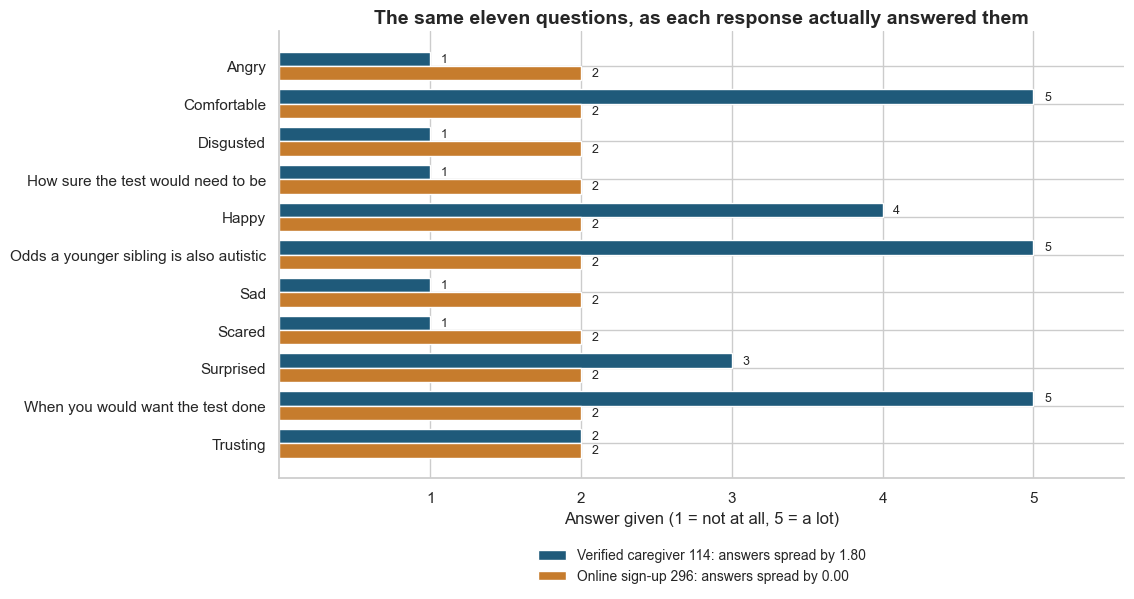

In [7]:
answer_comparison = ba.build_answer_comparison(screen_inputs, cache_dir)
display(answer_comparison)
ba.plot_answer_comparison(answer_comparison);

### The arithmetic behind that check

"Answers repeated down a block" is measured as the **spread** of the answers, which is their standard deviation. For $n$ answers $x_1 \dots x_n$ with average $\bar{x}$:

$$
\text{spread} \;=\; \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}}
$$

If every answer is the same, each gap $x_i - \bar{x}$ is zero, so the spread is exactly **0.00**.

The line for this block is **0.82**, which is the 1st percentile of the verified caregivers' spread. The cell below runs the formula on both responses, step by step.

In [8]:
flagged_id = answer_comparison.attrs["flagged_id"]
verified_id = answer_comparison.attrs["verified_id"]
limit = answer_comparison.attrs["limit"]

for who, column in [
    (f"Online sign-up {flagged_id}", f"Online sign-up {flagged_id} answered"),
    (f"Verified caregiver {verified_id}", f"Verified caregiver {verified_id} answered"),
]:
    answers = answer_comparison[column].astype(float)
    n = len(answers)
    average = answers.mean()
    squared_gaps = ((answers - average) ** 2).sum()
    spread = (squared_gaps / (n - 1)) ** 0.5
    verdict = "at or below the line, so this counts as repeated answers" if spread <= limit \
        else "above the line, so this does not count"

    print(who)
    print(f"  the {n} answers      : {[int(v) for v in answers]}")
    print(f"  average answer       : {average:.4f}")
    print(f"  sum of squared gaps  : {squared_gaps:.4f}")
    print(f"  spread               : sqrt({squared_gaps:.4f} / {n - 1}) = {spread:.4f}")
    print(f"  against the line 0.82: {verdict}")
    print()

Online sign-up 296
  the 11 answers      : [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  average answer       : 2.0000
  sum of squared gaps  : 0.0000
  spread               : sqrt(0.0000 / 10) = 0.0000
  against the line 0.82: at or below the line, so this counts as repeated answers

Verified caregiver 114
  the 11 answers      : [1, 5, 1, 1, 4, 5, 1, 1, 3, 5, 2]
  average answer       : 2.6364
  sum of squared gaps  : 32.5455
  spread               : sqrt(32.5455 / 10) = 1.8040
  against the line 0.82: above the line, so this does not count



## 2.2 The timing checks, on real section times

Same idea, applied to how long each section took. Response 1026 is one of the six responses the study marked as a confirmed bot.

A section counts as rushed when its time falls below that section's line:

$$t_{\text{section}} < L_{\text{section}}$$

,Survey section,Online sign-up 1026 (minutes),Verified caregiver 114 (minutes),Rushed-section line (minutes),Was this section rushed
0,Family Information minutes,0.85,3.93,0.79,No
1,Values minutes,0.10,2.68,0.68,Yes
2,Thoughts and feelings minutes,2.47,17.72,8.57,Yes
3,Demographics minutes,0.75,2.53,1.10,Yes
4,Whole survey,4.17,26.86,11.57,Yes


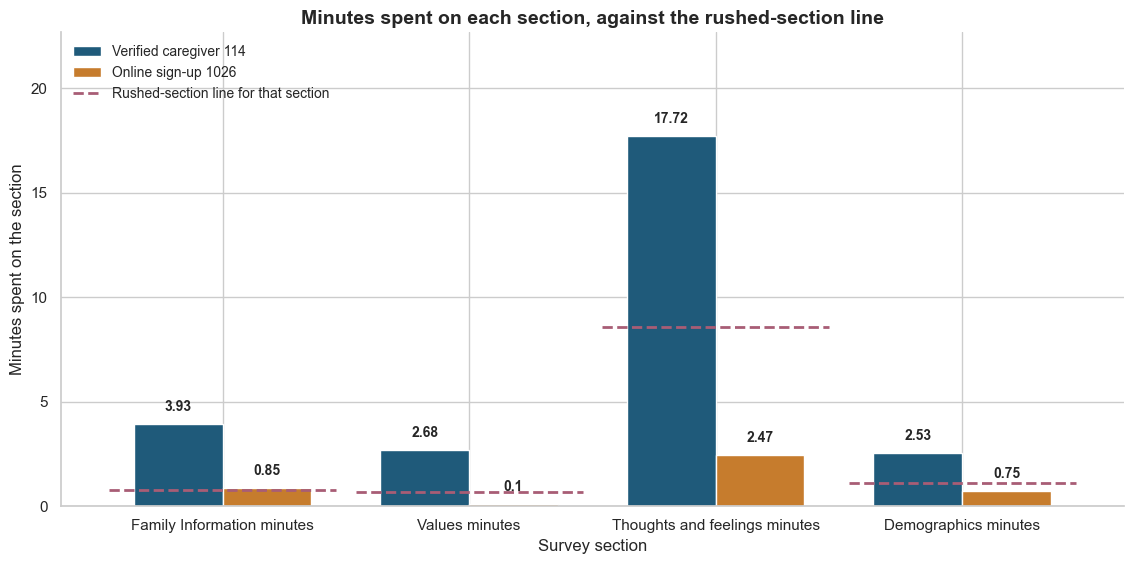

In [9]:
section_comparison = ba.build_section_time_comparison(screen_inputs, output_dir, cache_dir)
display(section_comparison)
ba.plot_section_time_comparison(section_comparison);

## 2.3 The Family Information check, on real answers

This check needs no timing and no statistics. It reads two answers from the same page and asks whether they can both be true.

A response says how many children it has, then ticks the age bands those children fall into. One child belongs to exactly one age band, so:

$$\text{age bands ticked} \;\le\; \text{children reported}$$

When that fails, the two answers contradict each other.

In [10]:
display(ba.build_family_contradiction_example(output_dir, cache_dir))

,Response,Children reported,Age bands ticked,Which age bands,Why this cannot be true
0,1069,2,3,"3 to 5 years, 6 to 10 years, 11 to 14 years","3 age bands need at least 3 children, but the response reported 2"
1,120,2,3,"Under 1 year, 11 to 14 years, 15 to 17 years","3 age bands need at least 3 children, but the response reported 2"
2,167,2,3,"1 to 2 years, 6 to 10 years, 11 to 14 years","3 age bands need at least 3 children, but the response reported 2"
3,1774,1,2,"11 to 14 years, 15 to 17 years","2 age bands need at least 2 children, but the response reported 1"


## 2.4 Five responses from start to finish

The first row is a verified caregiver, included so the four flagged responses have something to be read against. Read across each row: what the response said about its family, how it answered the ratings, how long it took, and what that produced.

In [11]:
display(ba.build_worked_examples(screen_inputs, output_dir=output_dir, cache_dir=cache_dir))

,Response,Family Information,"Thoughts, Feelings, and Attitudes",Timing and arrival,Why this response landed here,Decision
0,114 (verified caregiver),2 children; 1 autistic child; pregnancy item marked no; Family Information answers lin...,"Example item ratings: happy=4, scared=1, difficult=4, doable=1; answers moved across t...",Whole survey 26m 52s; Thoughts/Feelings/Attitudes 17m 43s,"This is the control row. It is a caregiver we verified, so it shows what the same four...",Cleared for payment now
1,1779,2 children; 0 autistic children; pregnancy item marked no; Family Information answers ...,"Example item ratings: happy=4, scared=3, difficult=4, doable=1; answers moved across t...",Whole survey 35m 32s; Thoughts/Feelings/Attitudes 28m 24s,"Nothing in the timings or answer pattern stood out, so this response stays in the pay-...",Cleared for payment now
2,1243,1 child; 1 autistic child; pregnancy item marked no; Family Information answers lined up.,"Example item ratings: happy=3, scared=4, difficult=3, doable=2; answers moved across t...",Whole survey 30m 50s; Thoughts/Feelings/Attitudes 21m 17s; Arrived inside a 1-minute c...,"Only one milder pattern showed up, so this response needs just a quick check before pa...",Low-risk provisional approval
3,1276,1 child; 1 autistic child; pregnancy item marked no; Family Information answers lined up.,"Example item ratings: happy=4, scared=4, difficult=3, doable=2; answers moved across t...",Whole survey 21m 14s; Thoughts/Feelings/Attitudes 16m 17s; Section below the verified-...,"2 milder patterns showed up together, so this response is held for review.",Needs human review
4,1355,2 children; 0 autistic children; pregnancy item marked no; Family Information answers ...,"Example item ratings: happy=5, scared=2, difficult=3, doable=2; answers moved across t...",Whole survey 10m 50s; Thoughts/Feelings/Attitudes 7m 41s; Section below the verified-c...,"2 strong patterns and 2 supporting patterns showed up, so this response is held for re...",Needs human review
5,1026,1 child; 1 autistic child; pregnancy item marked yes; Marked prenatal screening as yes...,"Example item ratings: happy=3, scared=5, difficult=2, doable=2; answers changed very l...",Whole survey 4m 10s; Thoughts/Feelings/Attitudes 2m 28s; Section below the verified-ca...,Very fast timing plus answer-pattern or Family Information problems put this response ...,Confirmed bot / reject


---
# 3. Does this hold across all the responses?

## 3.1 Timing

Blue bars are the verified caregiver sample. Orange bars are the online recruitment sample. Bars sit side by side, never on top of one another, so each group's height can be read directly.

The shaded area is the region the rule treats as too fast. No blue bar sits fully inside it, because the line was placed at the fastest verified caregiver.

,Group,Responses we could time,Middle time (minutes),Fastest time (minutes),Faster than the line
0,Caregivers we verified - whole survey,131,26.69,11.57,0 of 131
1,Online sign-ups - whole survey,"1,575",20.87,3.80,"283 of 1,575"
2,"Caregivers we verified - Thoughts, Feelings, and Attitudes section",131,18.93,7.85,0 of 131
3,"Online sign-ups - Thoughts, Feelings, and Attitudes section","1,587",12.22,2.05,"447 of 1,587"


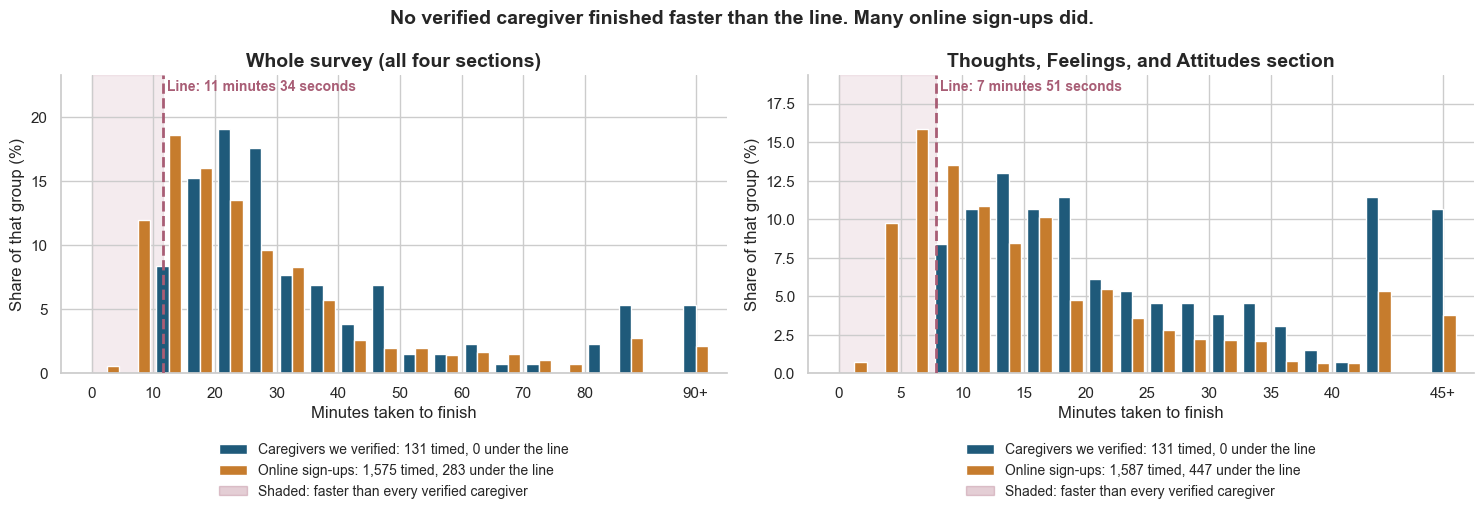

In [12]:
display(ba.build_speed_reference_table(screen_inputs))
ba.plot_speed_comparison(screen_inputs);

## 3.2 What happens if the attitudes line moves

Loosening the line catches more online sign-ups but starts catching verified caregivers too. The chart shows where that trade begins.

Read the two panels together: the top panel is what a line would catch, the bottom is who it would catch wrongly.

,Where we draw the line,"Online sign-ups caught (of 1,587)",Verified caregivers caught by mistake (of 131),What this setting means
0,4 minutes,80,0,"Catches no verified caregiver, but holds fewer online sign-ups"
1,5 minutes,167,0,"Catches no verified caregiver, but holds fewer online sign-ups"
2,6 minutes,260,0,"Catches no verified caregiver, but holds fewer online sign-ups"
3,7 minutes,375,0,"Catches no verified caregiver, but holds fewer online sign-ups"
4,7.85 minutes (today's setting),447,0,"Today's setting, and the loosest line that still catches no verified caregiver"
5,9 minutes,543,4,Pulls 4 verified caregiver(s) into the hold pile
6,10 minutes,633,11,Pulls 11 verified caregiver(s) into the hold pile
7,12 minutes,774,24,Pulls 24 verified caregiver(s) into the hold pile
8,15 minutes,939,42,Pulls 42 verified caregiver(s) into the hold pile


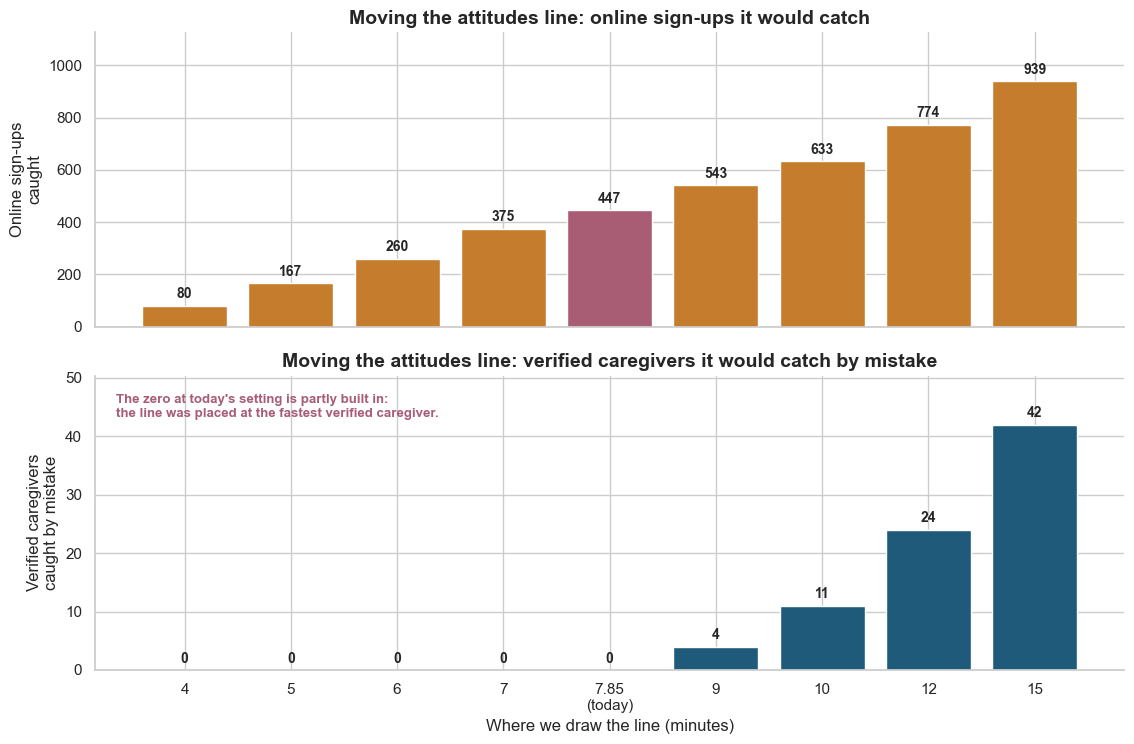

In [13]:
cutoff_sensitivity = ba.build_cutoff_sensitivity_table(screen_inputs)
display(cutoff_sensitivity)
ba.plot_cutoff_sensitivity(cutoff_sensitivity);

## 3.3 How often each check fires on people we know are real

This is the false alarm check. The count of verified caregivers each check could fire on changes by row, and the table says why: the two whole-timing checks can only fire on the 131 responses that were timed end to end.

The row to watch is **Age and location cannot both be true**. It has fired only in the verified sample and never in the online sample, so it works better as a review cue than as a reason to refuse payment.

In [14]:
display(ba.build_wrong_flag_table(screen_inputs))

,Pattern we look for,Where it shows up,How seriously we treat it,Verified caregivers this check could fire on,Verified caregivers it fired on,What that tells us,How to use it
0,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,177,12,This pattern showed up in 12 of 177 people we know are real.,"Use it to sort the queue, never on its own"
1,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,177,7,This pattern showed up in 7 of 177 people we know are real.,"Use it to sort the queue, never on its own"
2,Arrived within a minute of two or more others,Response arrival time,Supporting,177,6,This pattern showed up in 6 of 177 people we know are real.,"Use it to sort the queue, never on its own"
3,Age and location cannot both be true,Demographics,Serious,177,2,This pattern showed up in 2 of 177 people we know are real.,"Review this check. It has never fired on an online sign-up, only on people we know are..."
4,Whole survey too fast,Whole survey timing,Serious,131,0,"Zero here is partly built in: this line was placed at the fastest verified caregiver, ...",Strong enough to act on with a quick spot check
5,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,131,0,"Zero here is partly built in: this line was placed at the fastest verified caregiver, ...",Strong enough to act on with a quick spot check
6,Answer sheet identical to another response,Full answer pattern across the questionnaire,Serious,177,0,This pattern has not shown up in either study.,Strong enough to act on with a quick spot check
7,Family answers contradict each other,Family Information,Serious,177,0,"It never fired on a verified caregiver, and it fired on 44 online sign-ups.",Strong enough to act on with a quick spot check
8,Comment nearly identical to another,Open-text comment,Supporting,177,0,"It never fired on a verified caregiver, and it fired on 17 online sign-ups.",Strong enough to act on with a quick spot check


## 3.4 How often each pattern showed up in each group

Counts alone cannot be compared here, because the online sample is ten times larger. The chart uses shares so both groups sit on one scale, and the gap between each pair of bars is the evidence.

,Pattern,Where it shows up,How seriously we treat it,"Online sign-ups showing it (of 1,779)",Share of online sign-ups (%),Verified caregivers showing it (of 177),Share of verified caregivers (%)
0,Arrived within a minute of two or more others,Response arrival time,Supporting,1676,94.2,6,3.4
1,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,839,47.2,7,4.0
2,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,577,32.4,12,6.8
3,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,447,25.1,0,0.0
4,Whole survey too fast,Whole survey timing,Serious,283,15.9,0,0.0
5,Family answers contradict each other,Family Information,Serious,44,2.5,0,0.0
6,Comment nearly identical to another,Open-text comment,Supporting,17,1.0,0,0.0
7,Answer sheet identical to another response,Full answer pattern across the questionnaire,Serious,0,0.0,0,0.0
8,Age and location cannot both be true,Demographics,Serious,0,0.0,2,1.1


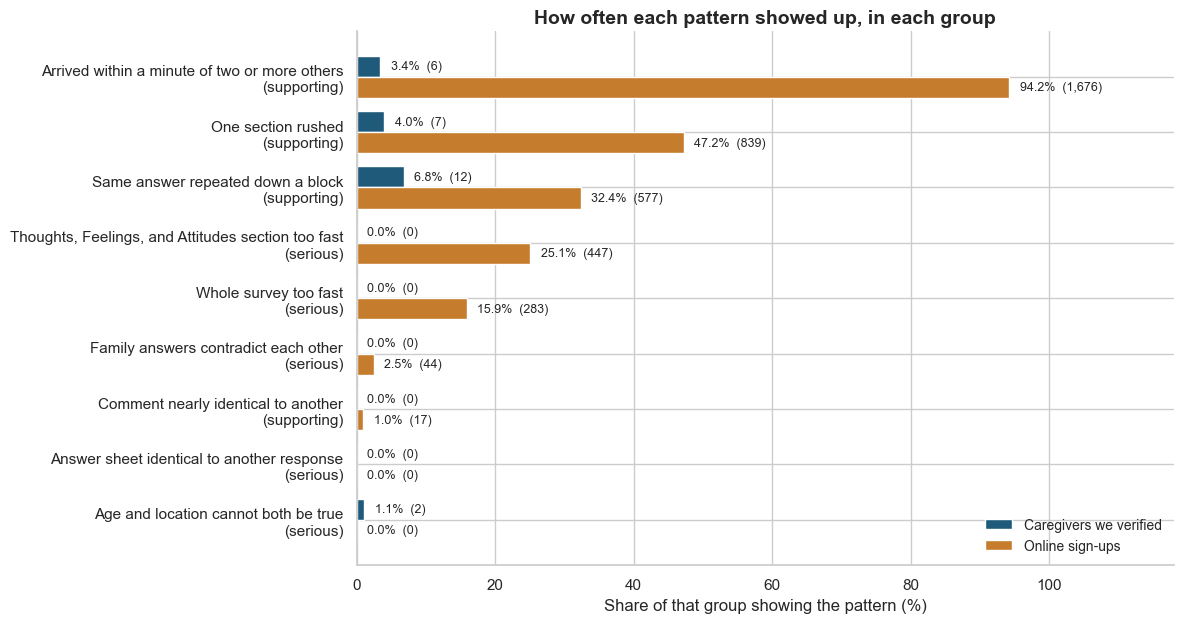

In [15]:
display(ba.build_all_checks_frequency_table(screen_inputs))
ba.plot_all_checks_frequency(screen_inputs);

## 3.5 How many patterns landed on one response

A response with **zero** patterns looks like response 1779. **One** looks like 1243. **Two or more** starts to look like 1276, 1355, or 1026.

One caveat on the dashed line: 46 of the 177 verified caregivers did not finish all four sections, so the two whole-timing checks could never fire on them. The ceiling of two checks in the verified group is real, but it is not measured on an identical footing.

,Number of patterns on one response,Caregivers we verified,Caregivers we verified (% of group),Online sign-ups,Online sign-ups (% of group)
0,0,153,86.4,70,3.9
1,1,21,11.9,662,37.2
2,2,3,1.7,411,23.1
3,3,0,0.0,275,15.5
4,4,0,0.0,239,13.4
5,5,0,0.0,114,6.4
6,6,0,0.0,8,0.4


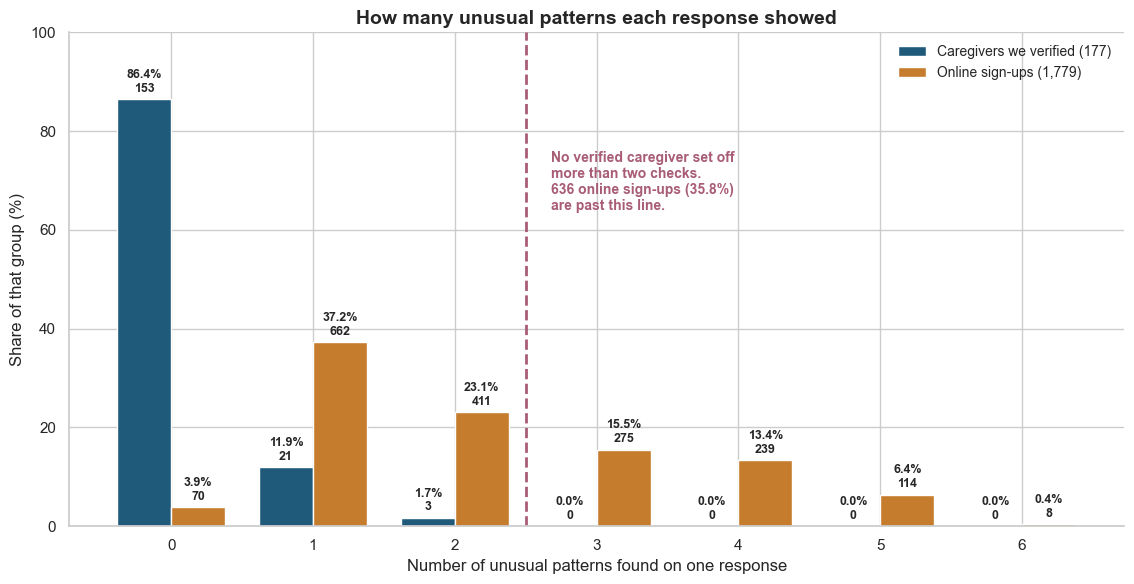

In [16]:
display(ba.build_checks_set_off_table(screen_inputs))
ba.plot_checks_set_off(screen_inputs);

## 3.6 How closely the sign-ups arrived

The burst check asks how close together sign-ups arrived, so this chart measures the **gap between each sign-up and the one before it**. That is the quantity the check reads.

A chart of sign-ups per day would not answer this. 100 verified caregivers also arrived on a single day, spread calmly across it, and a daily chart makes that look like the same behaviour it is not.

,Gap to the sign-up before it,Caregivers we verified (count),Caregivers we verified (% of group),Online sign-ups (count),Online sign-ups (% of group)
0,Under 1 minute,25,14.2,1716,96.5
1,1 to 5 minutes,44,25.0,6,0.3
2,5 to 30 minutes,41,23.3,33,1.9
3,30 minutes or more,66,37.5,23,1.3


Middle gap between online sign-ups: 4 seconds.
Middle gap between verified caregivers: 11 minutes.
96.5% of online sign-ups arrived under a minute after the one before, against 14.2% of verified caregivers.


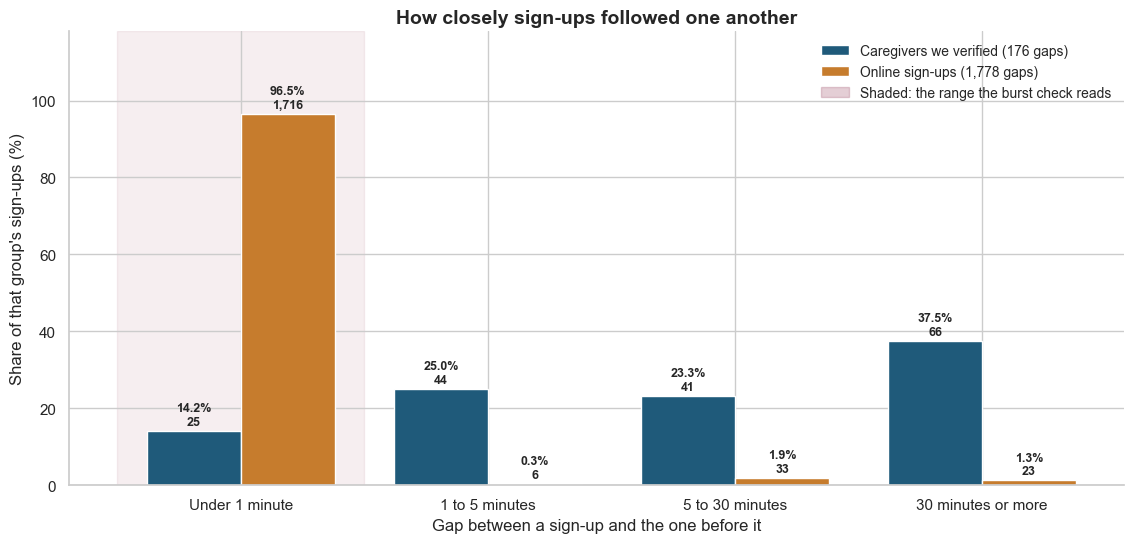

In [17]:
arrival = ba.build_arrival_tables(screen_inputs)
facts = arrival["surge_facts"]

display(arrival["gap_table"])

print(
    f"Middle gap between online sign-ups: {facts['median_gap_seconds']:.0f} seconds.\n"
    f"Middle gap between verified caregivers: {facts['verified_median_gap_minutes']:.0f} minutes.\n"
    f"{facts['online_under_minute_pct']:.1f}% of online sign-ups arrived under a minute after the one "
    f"before, against {facts['verified_under_minute_pct']:.1f}% of verified caregivers."
)
ba.plot_arrival_pattern(screen_inputs);

### What the surge day produced

The three days before the surge hold only 57 responses, so treat them as a small comparison group.

In [18]:
display(arrival["surge_crosstab"])
print(
    f"On {facts['surge_day']:%d %b %Y}, {facts['surge_n']:,} of the {facts['online_n']:,} online "
    f"sign-ups arrived, {facts['busiest_n']:,} of them inside four hours."
)

Payment Decision,When it arrived,Responses,Cleared for payment now,Low-risk provisional approval,Needs human review,Confirmed bot / reject
0,The three days before it,57,36,10,11,0
1,Surge day (06 Sep),1722,34,650,1032,6


On 06 Sep 2025, 1,722 of the 1,779 online sign-ups arrived, 1,717 of them inside four hours.


---
# 4. What the rule produced, and what it misses

## 4.1 The payment groups

In [19]:
display(action_summary)
display(timing_summary)
display(study_action_summary)

,Action group,Records,Share of all responses,What to do
0,Pay now,223,11.4%,Send gift card now
1,Low-risk approval,679,34.7%,Approve after quick check
2,Review,1048,53.6%,Hold for human review
3,Do not pay,6,0.3%,Do not pay


,Action group,Study 2 records,Median full survey time,Median attitudes time
0,Pay now,70,35.54 min,23.35 min
1,Low-risk approval,660,30.23 min,19.65 min
2,Review,1043,15.25 min,8.52 min
3,Do not pay,6,9.63 min,4.40 min


,Study,Action group,Records,Share within study (%),What to do
0,Study 1 - verified caregiver sample,Pay now,153,86.4,Send gift card now
1,Study 1 - verified caregiver sample,Low-risk approval,19,10.7,Approve after quick check
2,Study 1 - verified caregiver sample,Review,5,2.8,Hold for human review
3,Study 1 - verified caregiver sample,Do not pay,0,0.0,Do not pay
4,Study 2 - online recruitment sample,Pay now,70,3.9,Send gift card now
5,Study 2 - online recruitment sample,Low-risk approval,660,37.1,Approve after quick check
6,Study 2 - online recruitment sample,Review,1043,58.6,Hold for human review
7,Study 2 - online recruitment sample,Do not pay,6,0.3,Do not pay


The median times above describe the responses inside each payment group. They are not the lines. The lines are the stricter verified caregiver values shown in section 1.

## 4.2 How heavy is the hold pile

Some held responses have only timing or arrival concerns. Others combine timing with Family Information or answer-pattern problems.

In [20]:
display(hold_pile_mix)

,Pattern inside the Study 2 hold pile,Records,Share of hold pile (%),How to read it
0,Timing or arrival only,560,53.4,No strong contradiction; these were held because milder timing or arrival patterns pil...
1,One strong questionnaire concern,207,19.7,"One stronger issue is present, but not enough on its own for a do-not-pay decision."
2,Two strong concerns,279,26.6,Two stronger issues show up on the same record; this is the clearest part of the hold ...
3,Three or more strong concerns,3,0.3,Very concentrated concern; this is the strongest end of the hold pile.


## 4.3 What is driving the holds

Three numbers per pattern, drawn side by side because they overlap: one response can be counted in more than one of them.

Arrival timing is the single biggest driver. Switching it off would release 400 responses, so it is worth confirming this is meant as a payment rule and not just background context.

,Pattern,Where it shows up,How seriously we treat it,Online sign-ups showing it,Times it was the only issue on the response,Responses released if we removed it
0,Arrived within a minute of two or more others,Response arrival time,Supporting,1676,641,400
1,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,839,6,216
2,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,577,13,189
3,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,447,0,0
4,Whole survey too fast,Whole survey timing,Serious,283,0,1
5,Family answers contradict each other,Family Information,Serious,44,2,9
6,Comment nearly identical to another,Open-text comment,Supporting,17,0,1


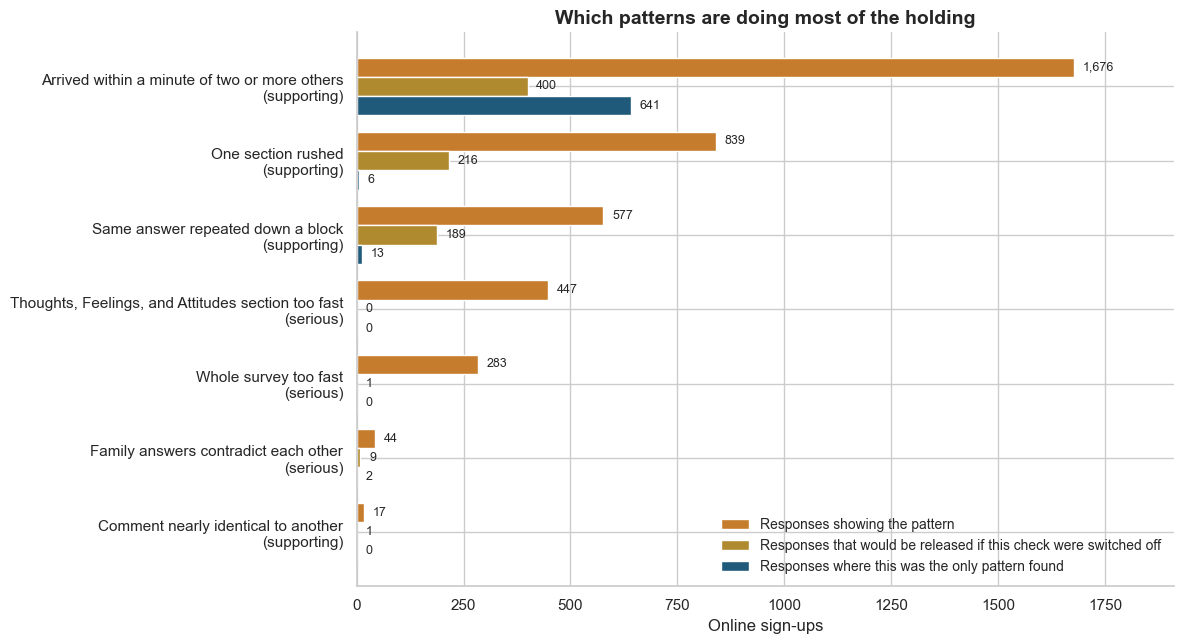

In [21]:
check_impact = ba.build_check_impact_table(screen_inputs)
display(check_impact)
ba.plot_check_impact(check_impact);

## 4.4 Where the timing checks cannot reach

Every timing check needs a recorded time. A blank or half-started form slips past all of them unless something else contradicts.

Watch the bottom row: 111 responses cleared the sign-up screen and then left the survey blank. All 111 were approved to pay. No timing rule can reach them, because there is no timed section to compare.

In [22]:
display(ba.build_timing_coverage_table(screen_inputs))

,What we were able to time,Responses,Approved to pay,Held for review or rejected
0,All four sections timed,1575,574,1001
1,"Some sections timed, attitudes section missing",81,40,41
2,"Some sections timed, one other section missing",12,5,7
3,No timing at all,111,111,0


## 4.5 Where to start, and what it costs

The hold pile worked worst first, at a planning assumption of 8 minutes per response.

In [23]:
display(ba.build_work_plan_table(screen_inputs, minutes_per_response=8))

,"Batch, worst first",Responses in this batch,Responses checked once this batch is done,"Responses that beat the fastest verified caregiver, found so far",Hours of staff time at 8 minutes each,Responses still unchecked
0,Set off 5 or 6 checks,117,117,117 of 445,16,926
1,Set off 4 checks,238,355,353 of 445,47,688
2,Set off 3 checks,275,630,444 of 445,84,413
3,Set off 2 checks or fewer,413,1043,445 of 445,139,0


Working the most concerning part of the pile first reaches almost every response that finished faster than the verified sample. The rest are not cleared. They need a different kind of review.

---
# 5. Turning the checks into points

Everything up to here answers each check with a yes or a no. That is hard to act on once a response breaks four checks of very different weight. A response that only arrived in a busy minute is not the same as one whose family answers contradict each other, but a yes and a yes look identical.

So the checks get added up instead.

- A **serious** check adds **2 points**.
- A **mild** check adds **1 point**.
- **3 points or more** means do not pay.
- **1 or 2 points** means a person reads the response before any money goes out.
- **0 points** means pay now.

Two checks below are new. One reads the email address. One reads the clock time the response signed up.

## 5.1 Every check, and what it is worth

In [24]:
risk_table = ba.build_risk_table(output_dir, cache_dir, project_dir)
display(ba.build_check_weight_table())

,Check,Where in the survey,How seriously we treat it,Points it adds,Where the line came from
0,Whole survey finished faster than any verified caregiver,Whole survey timing,Serious,2,Fastest of the 131 verified caregivers
1,Whole survey time sits inside the uncertainty band,Whole survey timing,Mild,1,"Redrawing the verified caregivers 4,000 times over"
2,Thoughts and feelings section faster than any verified caregiver,Thoughts and feelings timing,Serious,2,Fastest of the 131 verified caregivers
3,Thoughts and feelings time sits inside the uncertainty band,Thoughts and feelings timing,Mild,1,"Redrawing the verified caregivers 4,000 times over"
4,One of the four sections finished below its own speed line,Section timing,Mild,1,"Slowest 1 in 100 verified caregivers, section by section"
5,The same answer repeated down a rating block,Rating blocks,Mild,1,"Slowest 1 in 100 verified caregivers, block by block"
6,Answer sheet identical to another response,Whole questionnaire,Serious,2,Exact match on the full answer sheet
7,Arrived within a minute of two or more other sign-ups,Arrival time,Mild,1,"Sixty seconds, set by hand, not read off the caregivers"
8,Written comment nearly identical to another response,Open text,Mild,1,Written comments at least 90 percent alike
9,Family answers contradict each other,Family Information,Serious,2,Two answers on the same page that cannot both be true


## 5.2 A time limit is not a single number

Every time limit in section 1 came from the 131 verified caregivers who finished all four sections. A different 131 real caregivers would have produced a slightly different limit, so quoting one number hides how firm it really is.

The cell below draws 131 caregivers back out of that group at random, 4,000 times over, and records where the limit lands each time. The band is the middle 95 percent of those answers.

- **Below the band**: definitely rushed. This is the serious check, worth 2 points.
- **Inside the band**: possibly rushed. This is the new mild check, worth 1 point.
- **Above the band**: normal, and worth nothing.

For the whole survey and the thoughts and feelings section the limit is the fastest verified caregiver, so the band can only reach upward from it. That is why the band starts exactly on the limit already in use.

In [25]:
time_bands = ba.build_time_limit_bands(output_dir, cache_dir)
display(time_bands)
print(
    f"Bands drawn from the {time_bands.attrs['verified_n']} verified caregivers who finished "
    f"all four sections, redrawn {time_bands.attrs['repeats']:,} times."
)

,Part of the survey,How the limit was set,Limit in use (minutes),Limit in use,Band runs from (minutes),Band runs to (minutes),Below the band,Inside the band
0,Whole survey,Fastest verified caregiver,11.57,11 minutes 34 seconds,11.57,13.20,Definitely rushed,Possibly rushed
1,Thoughts and feelings section,Fastest verified caregiver,7.85,7 minutes 51 seconds,7.85,8.77,Definitely rushed,Possibly rushed
2,Family Information section,Slowest 1 in 100 verified caregivers,0.79,47 seconds,0.68,0.91,Definitely rushed,Possibly rushed
3,Values section,Slowest 1 in 100 verified caregivers,0.68,41 seconds,0.67,0.82,Definitely rushed,Possibly rushed
4,Demographics section,Slowest 1 in 100 verified caregivers,1.10,1 minute 6 seconds,0.72,1.30,Definitely rushed,Possibly rushed


Bands drawn from the 131 verified caregivers who finished all four sections, redrawn 4,000 times.


## 5.3 How often each check fired in each group

Counts first, then shares, because the online sample is ten times the size of the verified one.

The two email checks are worth reading closely. Not one response used a throwaway email service, so that check costs nothing and catches nothing here. The overnight check fires on five responses in total, two of them verified caregivers, so it should be read as a nudge and never as a reason on its own.

In [26]:
display(ba.build_check_frequency_table(risk_table))

,Check,How seriously we treat it,Points it adds,Verified caregivers,Online sign-ups,Share of verified caregivers,Share of online sign-ups
0,Whole survey finished faster than any verified caregiver,Serious,2,0 of 177,"283 of 1,779",0.0%,15.9%
1,Whole survey time sits inside the uncertainty band,Mild,1,3 of 177,"104 of 1,779",1.7%,5.8%
2,Thoughts and feelings section faster than any verified caregiver,Serious,2,0 of 177,"447 of 1,779",0.0%,25.1%
3,Thoughts and feelings time sits inside the uncertainty band,Mild,1,3 of 177,"78 of 1,779",1.7%,4.4%
4,One of the four sections finished below its own speed line,Mild,1,7 of 177,"839 of 1,779",4.0%,47.2%
5,The same answer repeated down a rating block,Mild,1,12 of 177,"577 of 1,779",6.8%,32.4%
6,Answer sheet identical to another response,Serious,2,0 of 177,"0 of 1,779",0.0%,0.0%
7,Arrived within a minute of two or more other sign-ups,Mild,1,6 of 177,"1,676 of 1,779",3.4%,94.2%
8,Written comment nearly identical to another response,Mild,1,0 of 177,"17 of 1,779",0.0%,1.0%
9,Family answers contradict each other,Serious,2,0 of 177,"44 of 1,779",0.0%,2.5%


## 5.4 What the points produce

The first table is the answer to the question the meeting actually asked: how many responses fall into each action, and how the two studies split across them.

The second table opens that up, showing every points total and how many responses sit on it.

In [27]:
display(ba.build_action_summary_table(risk_table))
display(ba.build_score_distribution_table(risk_table))

,Recommended action,Verified caregivers,Online sign-ups,All responses,Share of all responses,What this means
0,Pay now,152,68,220,11.2%,No points. Send the gift card.
1,Check by hand,22,1032,1054,53.9%,One or two points. A person should look before paying.
2,Do not pay,3,679,682,34.9%,3 points or more. Refuse payment.


,Risk score,Verified caregivers,Online sign-ups,All responses,Recommended action
0,0,151,66,217,Pay now
1,1,18,658,676,Check by hand
2,2,5,375,380,Check by hand
3,3,2,149,151,Do not pay
4,4,1,107,108,Do not pay
5,5,0,114,114,Do not pay
6,6,0,187,187,Do not pay
7,7,0,115,115,Do not pay
8,8,0,5,5,Do not pay
9,9,0,3,3,Do not pay


## 5.5 What the points do to people we already know are real

This is the cost side. Every verified caregiver is a real person, so anything the points refuse in that group is a refusal we would have made by mistake.

Three of the 177 verified caregivers reach 3 points. They are named below with the exact checks behind each one, because a rule that refuses real caregivers should be looked at rather than reported as a percentage.

In [28]:
display(ba.build_false_alarm_summary(risk_table))
display(ba.build_wrongly_refused_detail(risk_table))

,Recommended action,Verified caregivers,Share of the 177 verified caregivers
0,Pay now,152,85.9%
1,Check by hand,22,12.4%
2,Do not pay,3,1.7%


,Record ID,Whole survey minutes,Thoughts and feelings minutes,Whole survey speed,Thoughts and feelings speed,Which checks were broken,Risk score,Recommended action
0,143,12.05,7.85,Possibly rushed,Possibly rushed,Whole survey time sits inside the uncertainty band; Thoughts and feelings time sits in...,4,Do not pay
1,101,23.67,17.90,Normal,Normal,Age and location cannot both be true; Started between midnight and five in the morning,3,Do not pay
2,168,12.19,8.52,Possibly rushed,Possibly rushed,Whole survey time sits inside the uncertainty band; Thoughts and feelings time sits in...,3,Do not pay


Two of those three are cases where the maybe-rushed band did the damage. Record 143 finished in 12 minutes 3 seconds and record 168 in 12 minutes 11 seconds, both above the limit in use but inside the band, and both then picked up a third and fourth point from the milder checks. Record 101 is different: it took 23 minutes 40 seconds, so nothing about it was rushed, and its points come from an age and location answer that cannot both be true.

## 5.6 What is driving the refusals

The combinations below account for most of the 679 online sign-ups the points would refuse. Reading them tells you which checks are actually carrying the decision.

In [29]:
display(ba.build_top_reasons_table(risk_table))

,Checks broken together,Online sign-ups,Share of refused online sign-ups
0,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,155,22.8%
1,One of the four sections finished below its own speed line; The same answer repeated d...,110,16.2%
2,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,108,15.9%
3,Whole survey time sits inside the uncertainty band; Thoughts and feelings section fast...,50,7.4%
4,Thoughts and feelings section faster than any verified caregiver; One of the four sect...,49,7.2%
5,Thoughts and feelings section faster than any verified caregiver; One of the four sect...,37,5.4%
6,Thoughts and feelings time sits inside the uncertainty band; One of the four sections ...,30,4.4%
7,Whole survey time sits inside the uncertainty band; Thoughts and feelings section fast...,26,3.8%
8,Thoughts and feelings time sits inside the uncertainty band; One of the four sections ...,25,3.7%
9,The same answer repeated down a rating block; Arrived within a minute of two or more o...,19,2.8%


## 5.7 If the line moves

Setting the refusal line at 3 points was a choice, so here is what the other choices cost. Each row is a different line. The last two columns are the price of that line in real caregivers wrongly refused.

These counts are points only, worked out before the university email rule in section 5.8 is applied. That is why the row for 3 points names 680 online sign-ups while the action table in section 5.4 names 679.

In [30]:
display(ba.build_score_simulation_table(risk_table))

,Refuse payment at this many points or more,Online sign-ups refused,Share of online sign-ups refused,Verified caregivers refused by mistake,Share of verified caregivers refused by mistake,In use
0,1,"1,713",96.3%,26,14.7%,
1,2,"1,055",59.3%,8,4.5%,
2,3,680,38.2%,3,1.7%,Yes
3,4,531,29.8%,1,0.6%,
4,5,424,23.8%,0,0.0%,
5,6,310,17.4%,0,0.0%,
6,7,123,6.9%,0,0.0%,


Moving the line from 3 points to 5 removes every wrongly refused caregiver and still refuses 424 online sign-ups. Moving it down to 2 would refuse 1,055 online sign-ups but also 8 real caregivers.

The same question, asked of the whole survey time limit on its own.

In [31]:
display(ba.build_time_simulation_table(risk_table))

,Whole survey limit (minutes),Whole survey limit,Online sign-ups below it,Verified caregivers below it,Note
0,8.00,8 minutes,"88 of 1,575",0 of 131,
1,10.00,10 minutes,"197 of 1,575",0 of 131,
2,11.57,11 minutes 34 seconds,"283 of 1,575",0 of 131,The limit in use
3,13.20,13 minutes 12 seconds,"387 of 1,575",3 of 131,Top of the uncertainty band
4,15.00,15 minutes,"490 of 1,575",11 of 131,
5,18.00,18 minutes,"642 of 1,575",27 of 131,
6,20.00,20 minutes,"742 of 1,575",31 of 131,


## 5.8 Spot checks

Four quick lists to eyeball. Only the overnight one adds points; the rest are there to be looked at.

A university email address is treated as a sign of a real person. It clears a held response unless one of the contradiction checks fired, because no email address can explain away a family answer that contradicts itself. The second table below shows exactly how many responses that rule moved, so the decision is visible rather than buried.

Email addresses are shown here with the name shortened. The full addresses are in the spreadsheet, which is kept out of version control.

In [32]:
display(ba.build_spot_check_table(risk_table))
display(ba.build_email_override_effect(risk_table))
display(ba.build_university_email_list(risk_table))

,Spot check,What it is,Online sign-ups,All responses,How we use it
0,University email address,"The email ends in .edu, so a real person almost certainly holds it",3,7,Clears the response for payment unless a contradiction check fired
1,Started overnight,Sign-up between midnight and five in the morning,3,5,Adds one point
2,Arrived in a tight cluster,Ten or more other sign-ups landed within two minutes,1713,1713,"Listed for eyeballing only, adds no points"
3,Email domain seen only once,No other response used that email provider,8,16,"Listed for eyeballing only, adds no points"


,Question,Count
0,Responses with a university email address,7
1,"Of those, how many the points alone would have held",3
2,"Of those, how many the university email rule cleared",3
3,"Of those, how many stayed held because a contradiction check fired",0


,Study,Record ID,Email address,Whole survey minutes,Which checks were broken,Risk score,Action before email check,Recommended action,Cleared by university email
0,Study 1 - verified caregiver sample,14,s***@sc.edu,17.14,Arrived within a minute of two or more other sign-ups,1,Check by hand,Pay now,Yes
1,Study 1 - verified caregiver sample,41,e***@sc.edu,149.76,No checks broken,0,Pay now,Pay now,No
2,Study 1 - verified caregiver sample,153,c***@winthrop.edu,25.17,No checks broken,0,Pay now,Pay now,No
3,Study 1 - verified caregiver sample,156,b***@mailbox.sc.edu,15.62,No checks broken,0,Pay now,Pay now,No
4,Study 2 - online recruitment sample,180,h***@my.gcu.edu,35.13,One of the four sections finished below its own speed line; The same answer repeated d...,3,Do not pay,Pay now,Yes
5,Study 2 - online recruitment sample,618,c***@gator.uhd.edu,39.37,The same answer repeated down a rating block; Arrived within a minute of two or more o...,2,Check by hand,Pay now,Yes
6,Study 2 - online recruitment sample,35,j***@health.ucdavis.edu,38.85,No checks broken,0,Pay now,Pay now,No


---
# 6. What to do about the thousand in the middle

The points leave **1,032 online sign-ups** on 1 or 2 points. That is the pile nobody can work. At eight minutes a response it is 138 hours of reading, and it is the single biggest practical problem with the rule as it stands.

It turns out not to need 138 hours. The 1,032 responses only break **14 different combinations of checks between them**, and three of those combinations cover 1,000 of them. So the real question is not what to do about a thousand responses. It is what to do about a handful of situations.

## 6.1 One check is doing almost all of the work

1,005 of the 1,032 held responses carry the arrival check. Before deciding what that is worth, it is worth asking when it fired.

In [33]:
triaged = ba.build_review_triage(risk_table)
display(ba.build_arrival_by_day_table(risk_table))

,Day,Sign-ups that day,Arrived in a burst,Share of that day
0,2025-09-03,1,0,0.0%
1,2025-09-04,23,0,0.0%
2,2025-09-05,33,0,0.0%
3,2025-09-06,1722,1676,97.3%
4,All verified caregivers,177,6,3.4%


Every arrival flag in the study lands on **one day**, 6 September, and on that day **97 of every 100 sign-ups carry it**. Not one sign-up on any other day does.

That changes what the check means. It is strong evidence that something happened to the recruitment link on 6 September, because verified caregivers arrive that close together only 6 times in 177. But inside that day it separates nobody from anybody. A check that fires on 97 of every 100 people cannot tell you which of them to pay.

So the arrival check is treated as evidence about **the day**, and every other check as evidence about **the person**. Adding up only the checks about the person is what sorts the held pile below.

## 6.2 The held pile, sorted by what is actually against each response

In [34]:
triage_summary = ba.build_triage_summary(triaged)
display(triage_summary.drop(columns=["Why"]))
print(
    f"Held responses: {triage_summary.attrs['held_total']:,}. "
    f"Responses a person actually opens: {triage_summary.attrs['total_read']}."
)

,Review plan,Online sign-ups,Share of the held pile,Middle survey time (minutes),Responses a person actually reads
0,"Release, arrival timing only",544,52.7%,30.87,0
1,"Release, slower than a typical verified caregiver",145,14.1%,36.85,0
2,Read a random sample by hand,249,24.1%,19.27,59
3,Read every one by hand,2,0.2%,32.34,2
4,Hold until the completion rule is set,92,8.9%,no time recorded,0


Held responses: 1,032. Responses a person actually opens: 61.


That is the answer: **1,032 responses become 61 that someone reads.**

The reason for each group, in full:

In [35]:
display(triage_summary[["Review plan", "Online sign-ups", "Why"]])

,Review plan,Online sign-ups,Why
0,"Release, arrival timing only",544,"The only check against this response was arrival timing, and that check is about the d..."
1,"Release, slower than a typical verified caregiver",145,"Only mild checks fired, and this response spent longer on the survey than the typical ..."
2,Read a random sample by hand,249,"Only mild checks fired, but this response finished faster than the typical verified ca..."
3,Read every one by hand,2,"A serious check fired that describes what this person answered, not when they arrived."
4,Hold until the completion rule is set,92,"No section of this response has a recorded time, so no timing check can reach it. This..."


## 6.3 Why releasing 689 of them is safe

The two release groups are not being waved through on faith. They are being released because they took **longer on the survey than the caregivers we already know are real**.

In [36]:
display(ba.build_triage_time_comparison(triaged))

,Group,Responses,Middle whole-survey time (minutes),Middle thoughts and feelings time (minutes),Against the typical verified caregiver
0,Caregivers we verified,177,26.69,18.93,slower
1,"Release, arrival timing only",544,30.87,19.65,slower
2,"Release, slower than a typical verified caregiver",145,36.85,22.5,slower
3,Read a random sample by hand,249,19.27,11.35,faster
4,Read every one by hand,2,32.34,17.13,slower
5,Hold until the completion rule is set,92,no time recorded,no time recorded,no time recorded
6,Online sign-ups we refuse,679,12.3,6.58,faster


Read the last column. The typical verified caregiver spent 26 minutes 41 seconds on the survey. The 544 responses held on arrival timing alone spent 30 minutes 52 seconds. The 145 held on a mild check spent 36 minutes 51 seconds. Both groups sat with the survey longer than the real caregivers did, while the responses the points refuse spent 12 minutes 18 seconds, under half the verified figure.

Something filling in a survey automatically has no reason to spend half an hour doing it.

## 6.4 The group that does need reading, and how much of it

249 responses broke a mild check **and** finished faster than the typical verified caregiver. That is not damning, but it is not nothing, and 249 is still too many to open individually.

Reading a random sample answers it. If a person reads a sample and finds none of them fake, that puts a ceiling on how much of the group could be fake.

In [37]:
sample_plan = ba.build_sample_plan_table(triaged)
display(sample_plan)
print(f"Group size: {sample_plan.attrs['group_size']}.")

,Responses read at random,Hours at 8 minutes each,"If none of them are fake, at most this share of the group is fake",Which is at most this many responses,Suggested
0,20,2.7,13.9%,35,
1,30,4.0,9.5%,24,
2,45,6.0,6.4%,17,
3,59,7.9,5.0%,13,Yes
4,75,10.0,3.9%,10,
5,100,13.3,3.0%,8,
6,150,20.0,2.0%,5,
7,249,33.2,1.2%,3,


Group size: 249.


**59 responses, just under eight hours of reading.** If none of those 59 turn out to be fake, then at most 5 in 100 of the group is fake, which is at most 13 of the 249. If some of them do turn out to be fake, that rate is the number to apply to the whole group, and the group goes back on the refuse pile.

The sample is drawn in advance and written into the spreadsheet, so nobody picks which ones to read.

## 6.5 The short list, opened one at a time

In [38]:
display(ba.build_read_by_hand_list(triaged))

,Study,Record ID,Whole survey minutes,Thoughts and feelings minutes,Which checks were broken,Risk score,Review plan,Why this plan
0,Study 1 - verified caregiver sample,89,22.13,13.13,Age and location cannot both be true,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."
1,Study 2 - online recruitment sample,31,NaN,NaN,Family answers contradict each other,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."
2,Study 2 - online recruitment sample,52,32.34,17.13,Family answers contradict each other,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."


Three responses in the whole study need an individual decision. Two online sign-ups whose family answers contradict each other, and one verified caregiver whose age and location cannot both be true.

## 6.6 Where every response ends up

In [39]:
display(ba.build_final_plan_summary(triaged))

,Final plan,Verified caregivers,Online sign-ups,All responses,Someone reads it
0,Pay now,152,68,220,No
1,"Release, arrival timing only",3,544,547,No
2,"Release, slower than a typical verified caregiver",5,145,150,No
3,Read a random sample by hand,13,249,262,A sample of them
4,Read every one by hand,1,2,3,"Yes, every one"
5,Hold until the completion rule is set,0,92,92,"No, this needs a completion rule first"
6,Do not pay,3,679,682,No


The 92 held for a completion rule are the honest gap. They never produced a single timed section, so no timing check can reach them and no amount of reading will settle them. They are not a bot question. They are the question of whether an unfinished survey earns a gift card, and that is a decision to make once and apply to all 92.

## 6.7 The exact check combinations inside each group

For anyone who wants to see the sorting rather than trust it.

In [40]:
display(ba.build_triage_check_mix(triaged))

,Review plan,Which checks were broken,Online sign-ups
0,"Release, arrival timing only",Arrived within a minute of two or more other sign-ups,544
1,"Release, slower than a typical verified caregiver",The same answer repeated down a rating block; Arrived within a minute of two or more o...,87
2,"Release, slower than a typical verified caregiver",One of the four sections finished below its own speed line; Arrived within a minute of...,42
3,"Release, slower than a typical verified caregiver",The same answer repeated down a rating block,8
4,"Release, slower than a typical verified caregiver",One of the four sections finished below its own speed line,4
5,"Release, slower than a typical verified caregiver",One of the four sections finished below its own speed line; The same answer repeated d...,2
6,"Release, slower than a typical verified caregiver",Arrived within a minute of two or more other sign-ups; Written comment nearly identica...,1
7,"Release, slower than a typical verified caregiver",The same answer repeated down a rating block; No email address on a finished form,1
8,Read a random sample by hand,One of the four sections finished below its own speed line; Arrived within a minute of...,138
9,Read a random sample by hand,The same answer repeated down a rating block; Arrived within a minute of two or more o...,97


---
# 7. Two ways to lay out the rules that were broken

Everything so far writes the broken rules into one long sentence per response. That reads well and filters badly. Two tighter layouts were sketched for the spreadsheet, and both are produced below so the choice can be made by looking rather than describing.

**A grid.** Every rule gets its own column, and every cell is a Yes or a No.

**A list.** The rules go into a single cell, as codes and again in plain words.

They carry identical totals, so the two can never disagree with each other.

## 7.1 What each code means

R1 to R9 are the nine rules the study already names. E1 to E5 are the five checks added after the review meeting, kept on a separate letter so nobody mistakes a new one for an original.

In [41]:
display(ba.build_rule_key_table(triaged))

,Code,What it means,Where in the survey,Mild or serious,Points on the 1 and 5 scale,Points on the 1 and 2 scale,Added after the meeting,Verified caregivers it fired on,Online sign-ups it fired on
0,R1,Whole survey finished faster than any verified caregiver,Whole survey timing,Serious,5,2,No,0 of 177,"283 of 1,779"
1,R2,Thoughts and feelings section faster than any verified caregiver,Thoughts and feelings timing,Serious,5,2,No,0 of 177,"447 of 1,779"
2,R3,One of the four sections finished below its own speed line,Section timing,Mild,1,1,No,7 of 177,"839 of 1,779"
3,R4,The same answer repeated down a rating block,Rating blocks,Mild,1,1,No,12 of 177,"577 of 1,779"
4,R5,Answer sheet identical to another response,Whole questionnaire,Serious,5,2,No,0 of 177,"0 of 1,779"
5,R6,Arrived within a minute of two or more other sign-ups,Arrival time,Mild,1,1,No,6 of 177,"1,676 of 1,779"
6,R7,Written comment nearly identical to another response,Open text,Mild,1,1,No,0 of 177,"17 of 1,779"
7,R8,Family answers contradict each other,Family Information,Serious,5,2,No,0 of 177,"44 of 1,779"
8,R9,Age and location cannot both be true,Demographics,Serious,5,2,No,2 of 177,"0 of 1,779"
9,E1,Whole survey time sits inside the uncertainty band,Whole survey timing,Mild,1,1,Yes,3 of 177,"104 of 1,779"


## 7.2 The grid

One row per response, a Yes or a No in each of the fourteen rule columns.

One column here matters more than it looks. **Record numbers restart in each study**, so 348 numbers appear twice across the 1,956 responses. Record 100 is a verified caregiver and also an online sign-up. Any sheet keyed on the record number alone puts two different people on one row, so a **Response key** column carries the study number in front of the record number. Sort and filter on that.

In [42]:
rules_grid = ba.build_rules_grid(triaged)
print(f"Rows: {len(rules_grid):,}   Columns: {rules_grid.shape[1]}")
display(rules_grid.head(6))

Rows: 1,956   Columns: 24


,Study,Record ID,Response key,R1,R2,R3,R4,R5,R6,R7,...,E3,E4,E5,Total Rules Violated,Serious Rules Violated,Mild Rules Violated,"Scoring (Mild = 1, Serious = 5)","Scoring (Mild = 1, Serious = 2)",Recommended action,Final plan
0,Study 1 - verified caregiver sample,101,4797-101,No,No,No,No,No,No,No,...,No,No,Yes,2,1,1,6,3,Do not pay,Do not pay
1,Study 1 - verified caregiver sample,89,4797-89,No,No,No,No,No,No,No,...,No,No,No,1,1,0,5,2,Check by hand,Read every one by hand
2,Study 1 - verified caregiver sample,143,4797-143,No,No,Yes,Yes,No,No,No,...,No,No,No,4,0,4,4,4,Do not pay,Do not pay
3,Study 1 - verified caregiver sample,168,4797-168,No,No,Yes,No,No,No,No,...,No,No,No,3,0,3,3,3,Do not pay,Do not pay
4,Study 1 - verified caregiver sample,157,4797-157,No,No,Yes,No,No,No,No,...,No,No,No,2,0,2,2,2,Check by hand,Read a random sample by hand
5,Study 1 - verified caregiver sample,18,4797-18,No,No,No,Yes,No,Yes,No,...,No,No,No,2,0,2,2,2,Check by hand,Read a random sample by hand


## 7.3 The list

The same responses, with the rules written into one cell.

In [43]:
rules_list = ba.build_rules_list(triaged)
display(rules_list.head(6))

,Study,Record ID,Response key,Rules violated,"Rules violated, in plain words",Total Number of Rules,Serious Rules Violated,Mild Rules Violated,"Scoring (Mild = 1, Serious = 5)","Scoring (Mild = 1, Serious = 2)",Recommended action,Final plan
0,Study 1 - verified caregiver sample,101,4797-101,"R9, E5",Age and location cannot both be true; Started between midnight and five in the morning,2,1,1,6,3,Do not pay,Do not pay
1,Study 1 - verified caregiver sample,89,4797-89,R9,Age and location cannot both be true,1,1,0,5,2,Check by hand,Read every one by hand
2,Study 1 - verified caregiver sample,143,4797-143,"R3, R4, E1, E2",One of the four sections finished below its own speed line; The same answer repeated d...,4,0,4,4,4,Do not pay,Do not pay
3,Study 1 - verified caregiver sample,168,4797-168,"R3, E1, E2",One of the four sections finished below its own speed line; Whole survey time sits ins...,3,0,3,3,3,Do not pay,Do not pay
4,Study 1 - verified caregiver sample,157,4797-157,"R3, E2",One of the four sections finished below its own speed line; Thoughts and feelings time...,2,0,2,2,2,Check by hand,Read a random sample by hand
5,Study 1 - verified caregiver sample,18,4797-18,"R4, R6",The same answer repeated down a rating block; Arrived within a minute of two or more o...,2,0,2,2,2,Check by hand,Read a random sample by hand


## 7.4 Which one to use

In [44]:
display(ba.build_layout_choice_table())

,Layout,What one row looks like,Best for,Watch out for
0,Rules grid,A Yes or No in fourteen separate columns,"Filtering on one rule, sorting by it, counting how often two rules appear together","Fourteen narrow columns, so it is wide to read on paper"
1,Rules list,"One cell reading R1, R5, and a second cell spelling those out","Reading down a page, or pasting one response into an email",Cannot be filtered on a single rule without splitting the cell first


Both go in the spreadsheet, on their own tabs. The grid is the one to work in day to day, because a single rule can be filtered on. The list is the one to paste into an email about one response.

## 7.5 About counting a serious rule as 5

The sketch scored a mild rule 1 and a serious rule 5. The meeting notes scored a serious rule 2. Both are carried in every table above, side by side, because the choice changes who gets paid and should be made on purpose.

Two things happen when a serious rule counts 5 instead of 2.

In [45]:
display(ba.build_scale_comparison(triaged))

,Kind of response,Responses,Lowest score on the 1 and 5 scale,Highest score on the 1 and 5 scale,Lowest score on the 1 and 2 scale,Highest score on the 1 and 2 scale
0,No rules broken,217,0,0,0,0
1,Mild rules only,1248,1,5,1,5
2,Exactly one serious rule,209,5,10,2,7
3,Two or more serious rules,282,11,18,5,9


First, **a single serious rule on its own reaches 5 points**, so it clears any line of 3, 4, or 5. That is an automatic refusal on one rule, which the study has so far deliberately avoided. It affects 3 responses today, so it is a small consequence rather than a large one, but it is a change of principle.

Second, **five mild rules also reach 5 points**, so at a line of 5 a response with five mild concerns and a response with one serious one are treated the same. The 1 and 2 scale keeps them apart.

The line of 3 does not carry across. On the 1 and 5 scale it has to be picked again.

In [46]:
display(ba.build_heavy_cutoff_table(triaged))

,Refuse payment at this many points or more,Online sign-ups refused,Verified caregivers refused by mistake,Share of verified caregivers refused by mistake,What this line does,Note
0,3,682,4,2.3%,"Refuses any three mild rules, and any single serious rule","Same number as the line in use, but a much harsher line on this scale"
1,5,497,2,1.1%,Refuses any single serious rule on its own,
2,6,487,1,0.6%,Refuses a serious rule once anything else joins it,
3,7,480,0,0.0%,"Refuses a serious rule with two mild ones, or two serious rules",The lowest line here that refuses no verified caregiver
4,8,416,0,0.0%,"Refuses a serious rule with three mild ones, or two serious rules",
5,10,283,0,0.0%,Refuses two serious rules,
6,12,281,0,0.0%,Refuses two serious rules with two mild ones,


On this scale, **7 points is the first line that refuses no verified caregiver at all**. It refuses 480 online sign-ups, against 680 for the line in use now, so it is the more forgiving of the two and it makes no mistakes on the group we know is real.

That is a genuine option worth putting to the meeting: move to the 1 and 5 scale with a line of 7, and the three verified caregivers currently refused by mistake are no longer refused.

The arrival numbers are worth pausing on. The typical online sign-up landed with **38 other sign-ups inside a two minute window**. The typical verified caregiver landed with **none**. No verified caregiver ever had ten others land that close, which is where the tight cluster bar was set.

---
# 8. The spreadsheet

Two files come out of this notebook.

**The master file** lists all 1,956 responses. Each check has its own Yes or No column, the checks a response broke are also written out in one cell, and the points and the recommended action sit at the end. It carries email addresses, so it is written to a folder kept out of version control.

**The summary file** is the shorter overview, with no addresses in it.

## 8.1 A look at the master file

In [47]:
master_export = ba.build_master_export(risk_table)
print(f"Rows: {len(master_export):,}   Columns: {master_export.shape[1]}")
display(ba.build_master_preview(master_export, rows=8))

Rows: 1,956   Columns: 46


,Study,Record ID,Whole survey minutes,Whole survey speed,Thoughts and feelings speed,Which checks were broken,Checks broken,Risk score,Recommended action
0,Study 2 - online recruitment sample,1026,4.17,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,9,Do not pay
1,Study 2 - online recruitment sample,120,9.86,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,9,Do not pay
2,Study 2 - online recruitment sample,571,9.41,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,9,Do not pay
3,Study 2 - online recruitment sample,1119,11.36,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,8,Do not pay
4,Study 2 - online recruitment sample,1120,11.56,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,8,Do not pay
5,Study 2 - online recruitment sample,1330,10.06,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,8,Do not pay
6,Study 2 - online recruitment sample,1332,10.05,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,8,Do not pay
7,Study 2 - online recruitment sample,945,10.39,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,8,Do not pay


## 8.2 What every column holds

In [48]:
display(ba.build_master_column_guide(master_export))

,Column,What it holds
0,Study,Which of the two studies the response came from
1,Record ID,The response number in the survey system
2,Email address,"The address given on the demographics page, for spot checking"
3,University email address,Yes when the address ends in .edu
4,Started,When the sign-up screen was submitted
5,Last section handed in,When the last of the four sections was submitted
6,Started overnight,Yes when the sign-up landed between midnight and five in the morning
7,Family Information minutes,Minutes spent on the Family Information section
8,Values minutes,Minutes spent on the Values section
9,Thoughts and feelings minutes,"Minutes spent on the Thoughts, Feelings, and Attitudes section"


## 8.3 Writing both files

In [49]:
master_workbook = ba.export_master_workbook(
    output_dir=output_dir,
    cache_dir=cache_dir,
    project_dir=project_dir,
    source_table=source_table,
    audit_table=audit_table,
)
print(f"Master file: {master_workbook.relative_to(project_dir)}")
print(pd.ExcelFile(master_workbook).sheet_names)

report_workbook = ba.export_simple_excel(
    output_dir=output_dir,
    cache_dir=cache_dir,
    excel_filename="ESD_Bot_Analysis_Simple_Summary.xlsx",
)
print(f"\nSummary file: {report_workbook.relative_to(project_dir)}")
print(pd.ExcelFile(report_workbook).sheet_names)

Master file: Caregiver Outputs/restricted/ESD_Response_Review_Master.xlsx
['Read me first', 'Summary', 'All responses', 'Pay now', 'Check by hand', 'Do not pay', 'Checks and points', 'Time limits', 'If the line moves', 'Spot checks', 'Handling the held pile', 'Rule key', 'Rules grid', 'Rules list', 'Read by hand', 'Where the data came from']



Summary file: Caregiver Outputs/ESD_Bot_Analysis_Simple_Summary.xlsx
['Summary', 'Pay Now', 'Review Queue', 'Screen Guide', 'Extra Views']


---
# What the numbers say

**The time limits are defensible, and now they carry a band.** Every limit was recomputed from the raw answers in section 1.3 and matched. Section 5.2 adds the band around each one, so a response can be called definitely rushed, possibly rushed, or normal rather than being forced into a yes or a no.

**The points separate the two studies cleanly.** 151 of the 177 verified caregivers score zero, and 152 end up in the pay group once the university email rule is applied. The typical online sign-up scores 2. At the line the meeting set, 679 online sign-ups are refused and 3 verified caregivers are refused with them, which is 1.7 percent of the group we know is real.

**The line is a choice, and section 5.7 prices it.** Moving from 3 points to 5 clears every wrongly refused caregiver and still refuses 424 online sign-ups. That table is the one to bring to the next meeting.

**The thousand in the middle is not a thousand decisions.** Section 6 sorts the 1,032 held responses into five groups and leaves **61 responses for a person to open**: 2 read individually, and a 59-response random sample standing in for a group of 249. 689 are released because they spent longer on the survey than the caregivers we know are real, and 92 are held back for a completion decision rather than a bot decision.

**Arrival timing is the strongest study-level signal and the weakest person-level one.** 94.2 percent of online sign-ups arrived within a minute of another, against 3.4 percent of verified caregivers, so something clearly happened to the recruitment link. But every one of those flags falls on 6 September, and 97.3 percent of that day's sign-ups carry it, so it cannot pick one person out of the day. That is why it is set aside when deciding about an individual and kept when describing the study.

**The email checks cost nothing and add almost nothing.** No response used a throwaway email service. Seven responses carry a university address, and the rule cleared 3 of them that the points would otherwise have held. Six responses finished the survey and left the email box empty.

**The overnight check is too small to lean on.** Five responses in total, two of them verified caregivers. It is in the score at 1 point because the meeting asked for it, and it should stay a nudge.

**The biggest open question is unfinished forms.** 111 online responses have no timed section at all. The points system holds 92 of them and still pays 19. No timing check can reach any of them, so a completion rule is needed before payment goes out.

**The rules each response broke are laid out two ways.** A grid with a Yes or No column per rule, and a list with the rules in one cell. Both are in the spreadsheet and both carry the same totals. Sort either on the response key rather than the record number, because record numbers restart in each study and 348 of them appear twice.

**Counting a serious rule as 5 instead of 2 is a real option, not just a rescaling.** On that scale a line of 7 refuses 480 online sign-ups and refuses none of the verified caregivers, against 680 and 3 for the line in use now. It is more forgiving and it makes no mistakes on the group we know is real. The cost is that a single serious rule then refuses on its own, which affects 3 responses.

**Three decisions are needed before this can run.** Whether an unfinished survey earns a gift card, which scoring scale to use, and where the refusal line sits on it. Everything else is settled.